Employee Attrition Analysis 

Step 1:Load Required Packages

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

Step 2:Read the Employee Dataset

In [22]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


Step 3:Initial Dataset Inspection

In [23]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.sample(5, random_state=10)

Rows : 1470
Columns : 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
793,28,No,Travel_Rarely,895,Research & Development,15,2,Life Sciences,1,1102,1,Male,50,3,1,Laboratory Technician,3,Divorced,2207,22482,1,Y,No,16,3,4,80,1,4,5,2,4,2,2,2
689,20,Yes,Travel_Rarely,129,Research & Development,4,3,Technical Degree,1,960,1,Male,84,3,1,Laboratory Technician,1,Single,2973,13008,1,Y,No,19,3,2,80,0,1,2,3,1,0,0,0
1254,49,No,Travel_Rarely,1313,Sales,11,4,Marketing,1,1757,4,Female,80,3,2,Sales Executive,4,Single,4507,8191,3,Y,No,12,3,3,80,0,8,1,4,5,1,0,4
233,50,No,Travel_Rarely,854,Sales,1,4,Medical,1,323,4,Female,68,3,5,Manager,4,Divorced,19517,24118,3,Y,No,11,3,3,80,1,32,3,2,7,0,0,6
1403,39,No,Travel_Rarely,119,Sales,15,4,Marketing,1,1975,2,Male,77,3,4,Sales Executive,1,Single,13341,25098,0,Y,No,12,3,1,80,0,21,3,3,20,8,11,10


Step 4:Examine Dataset Structure

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Step 5:Generate Statistical Summary

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


Step 6:List All Variables

In [26]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

Step 7:Identify Data Types

In [27]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

Step 8:Check Missing Information

In [28]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Step 9:Detect Duplicate Entries

In [29]:
df.duplicated().sum()

np.int64(0)

Step 10:Count Unique Values

In [30]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

Step 11:Remove Unnecessary Columns

In [31]:
drop_columns = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]
df.drop(columns=drop_columns, inplace=True, errors='ignore')
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

Step 12:Verify Category Values

In [32]:
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].unique())


 Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

 Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

 EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

 Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

 MaritalStatus
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

 OverTime
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Step 13:Logical Data Validation

In [33]:
(df["YearsAtCompany"] > df["Age"]).sum()

np.int64(0)

Step 14:Detect Outliers

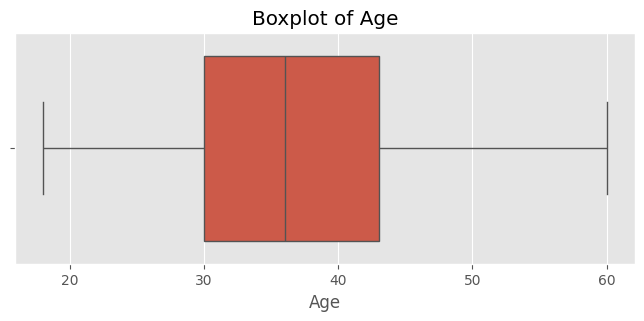

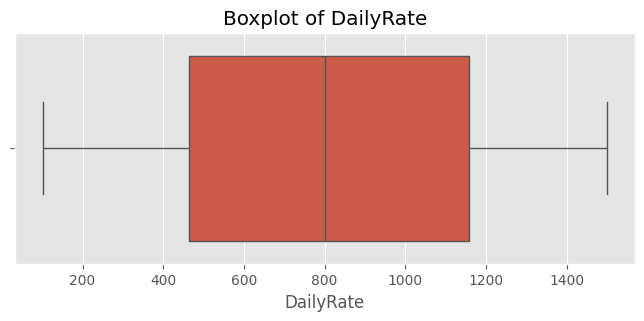

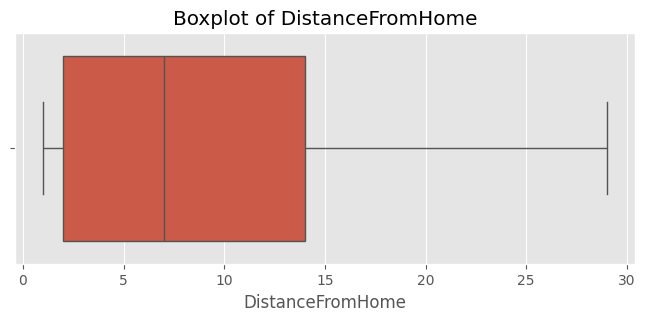

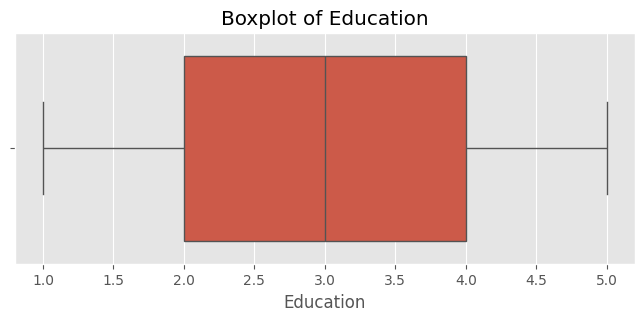

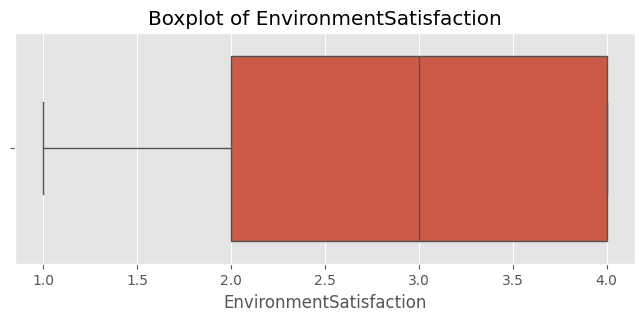

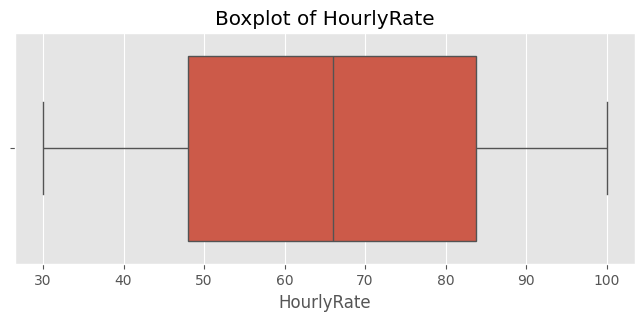

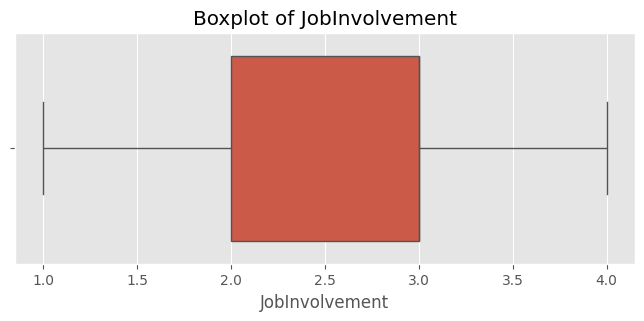

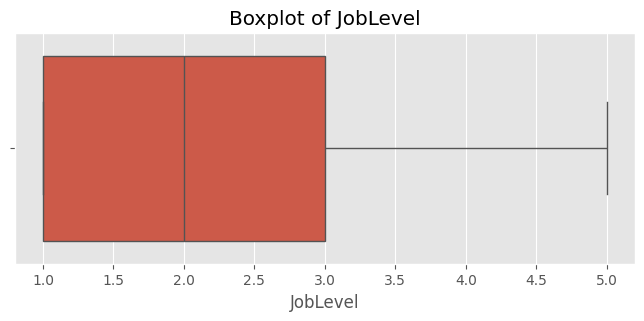

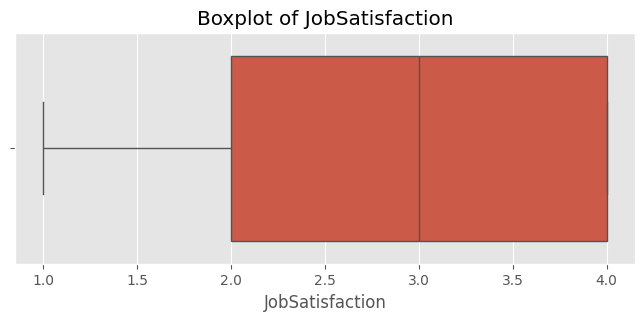

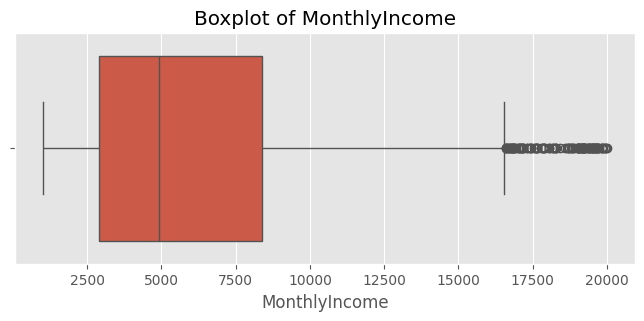

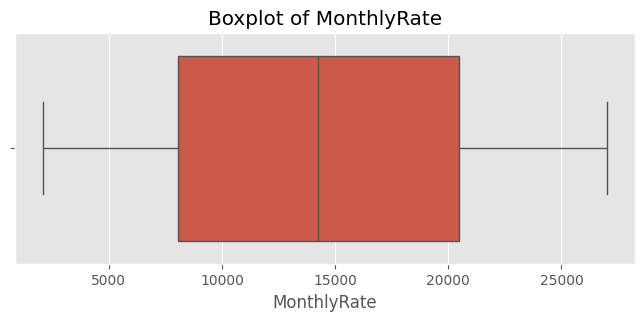

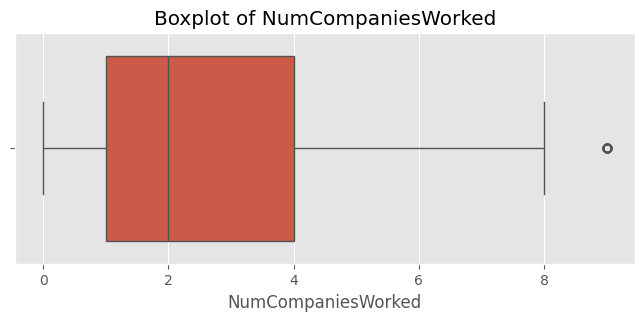

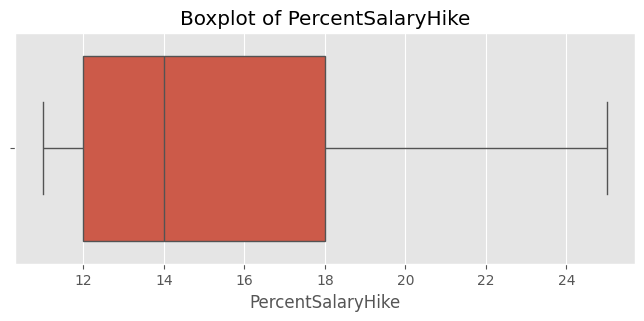

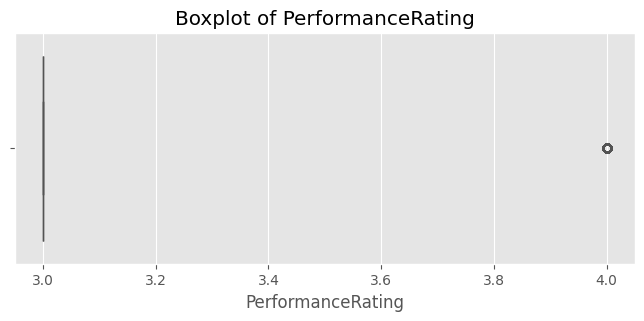

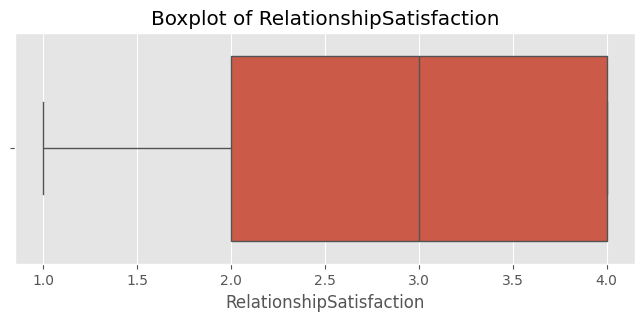

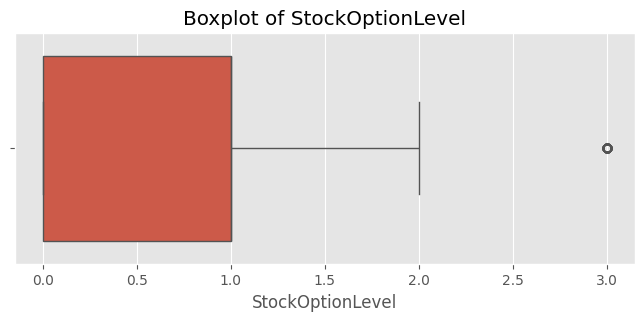

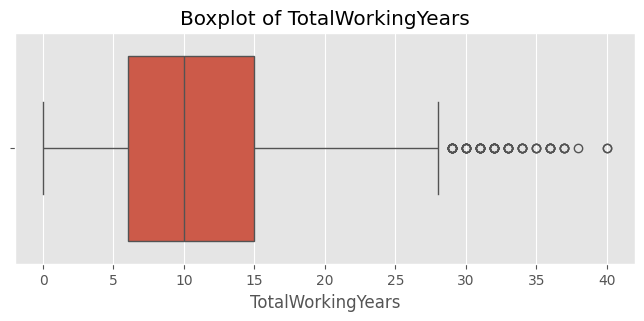

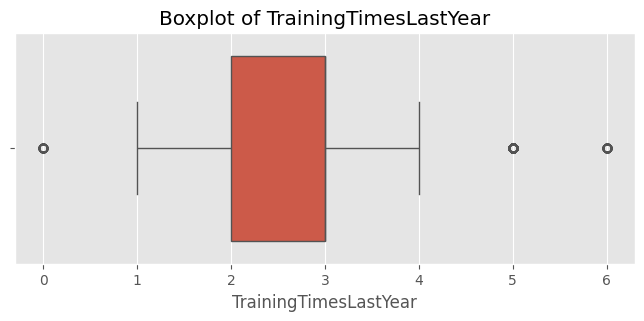

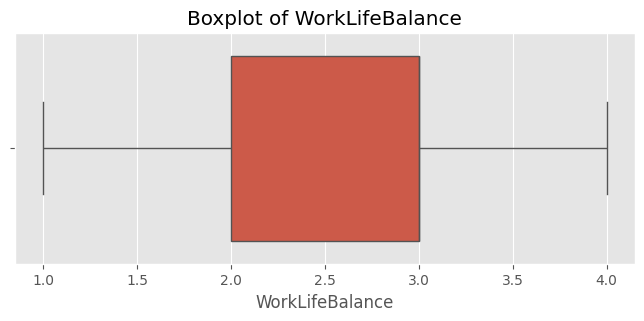

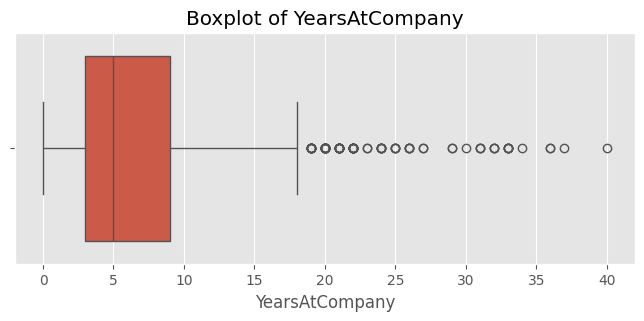

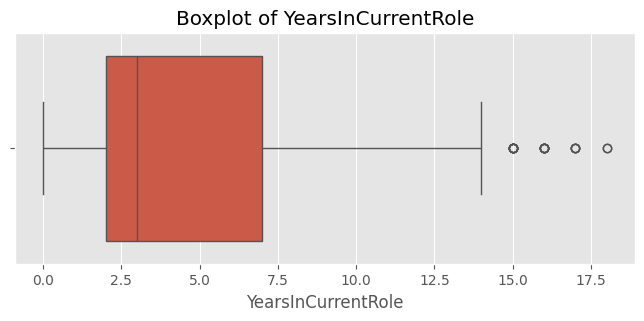

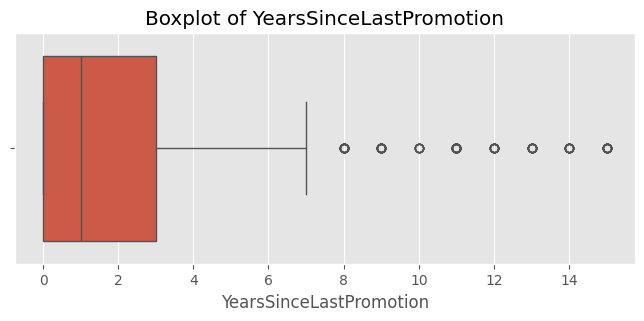

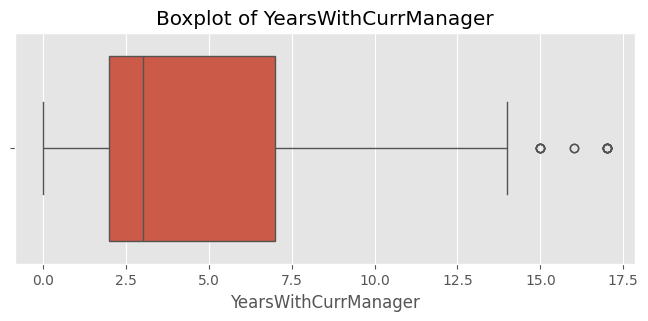

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Step 15:Seperate Numerical & Categorical Columns

In [35]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(include="object").columns
print(num_cols)
print(cat_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='str')


Step 16:Univariate Analysis

#Business Questions


1.What percentage of employees leave the company?

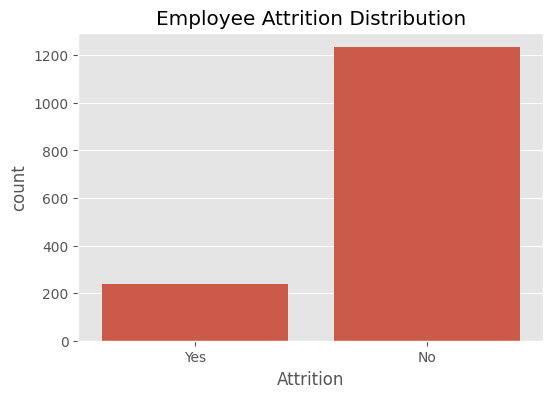

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()

2.Which department has the highest workforce?

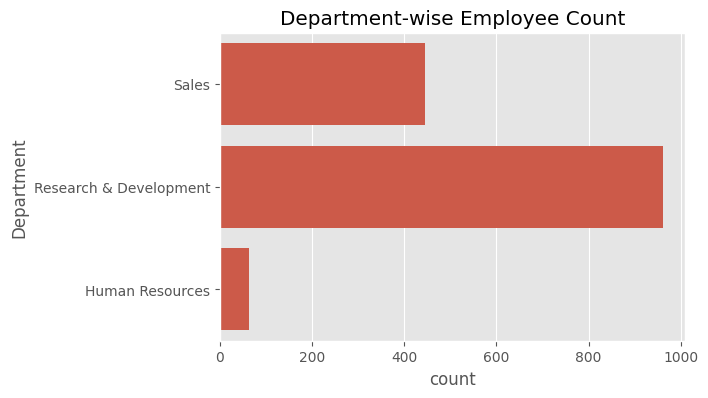

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(y="Department", data=df)
plt.title("Department-wise Employee Count")
plt.show()

3.Which job role has the maximum employees?

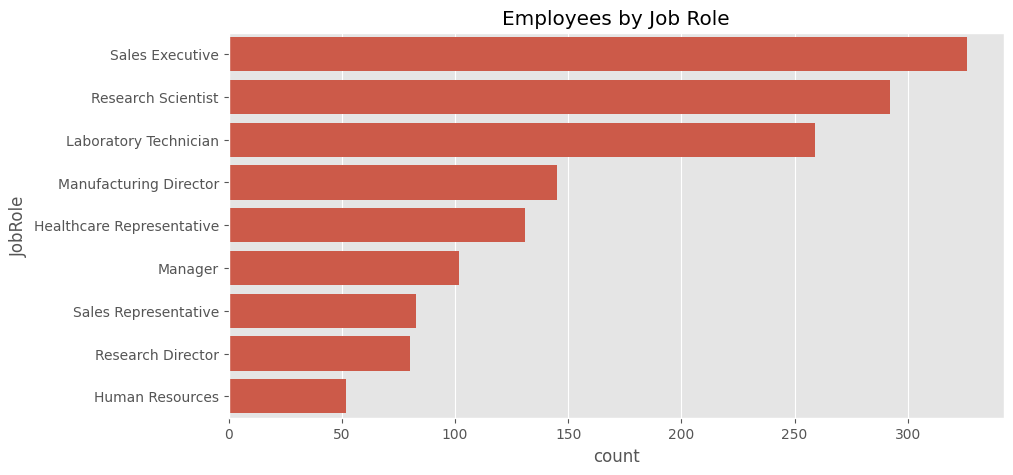

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(y="JobRole", data=df)
plt.title("Employees by Job Role")
plt.show()

4.How is employee age distributed?

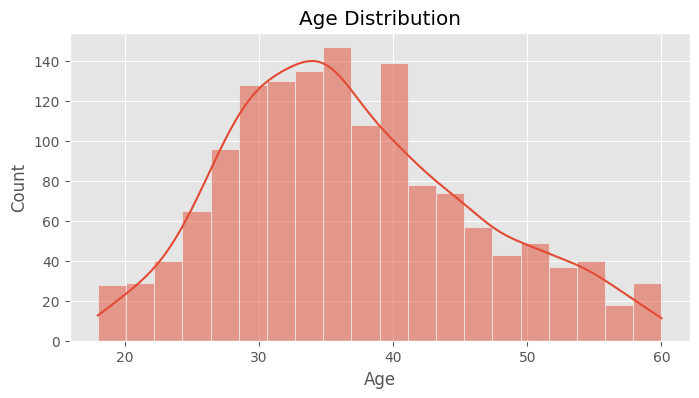

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

5.How is monthly salary distributed?

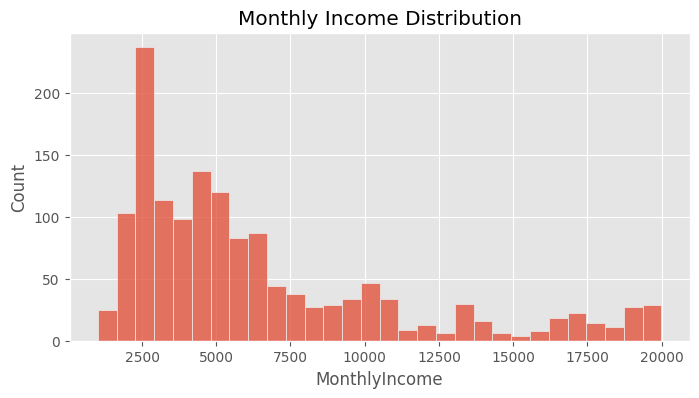

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df["MonthlyIncome"],bins=30)
plt.title("Monthly Income Distribution")
plt.show()

Step 17:Bivariate Analysis

#Questions

1.Does overtime influence attrition

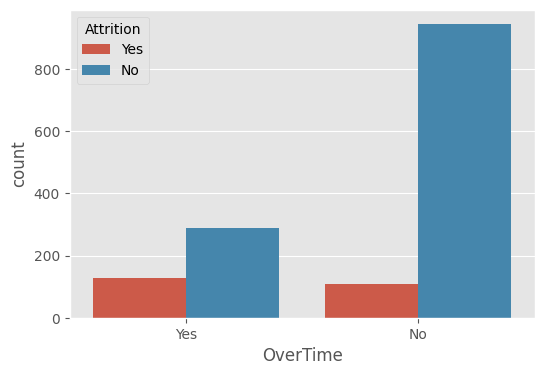

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="OverTime",
              hue="Attrition",
              data=df)
plt.show()

2.Which department experiences higher attrition?

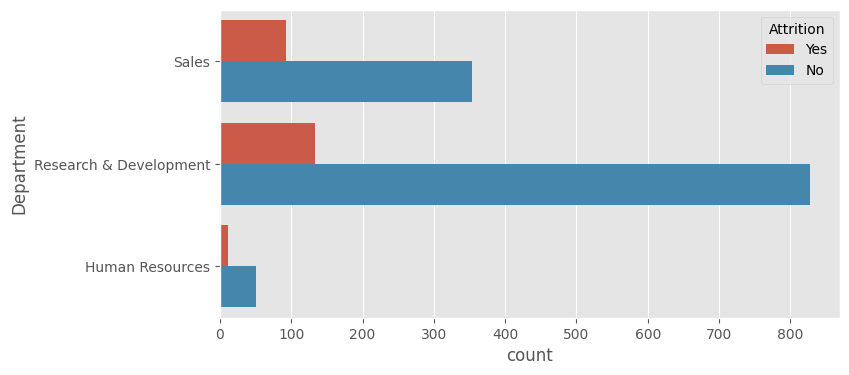

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(y="Department",
              hue="Attrition",
              data=df)
plt.show()

3.Does salary differ between reatined and exited employees?

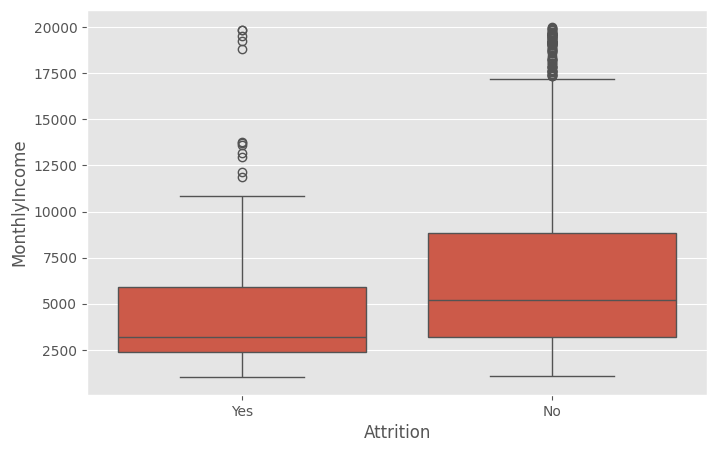

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition",
              y="MonthlyIncome",
              data=df)
plt.show()

4.Does work-life balance affect attrition?

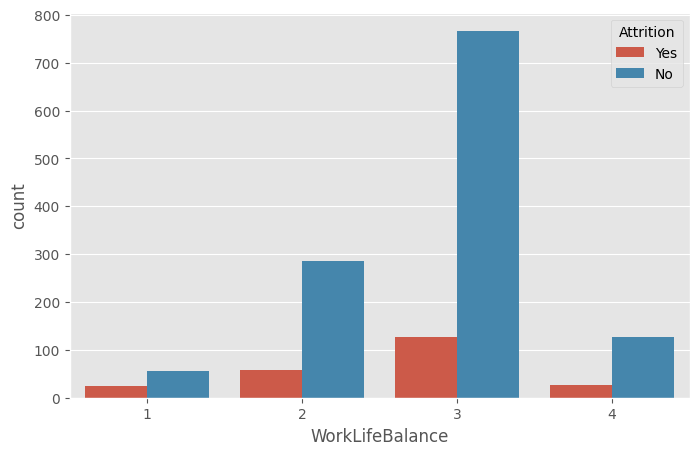

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="WorkLifeBalance",
              hue="Attrition",
              data=df)
plt.show()

5.Relationship between age and attrition

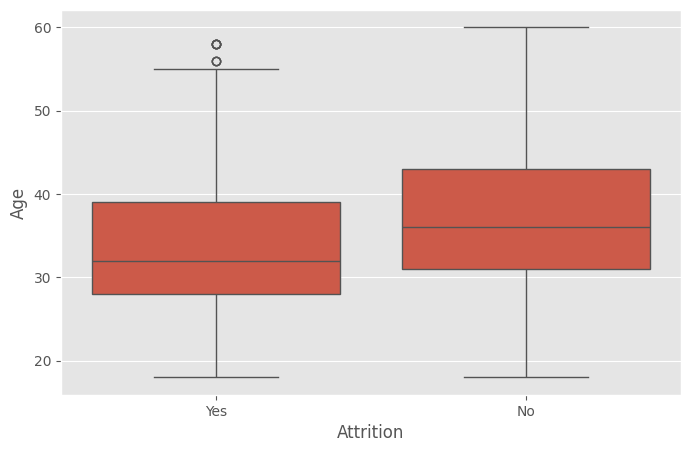

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition",
              y="Age",
              data=df)
plt.show()

Step 18:Correlation Study

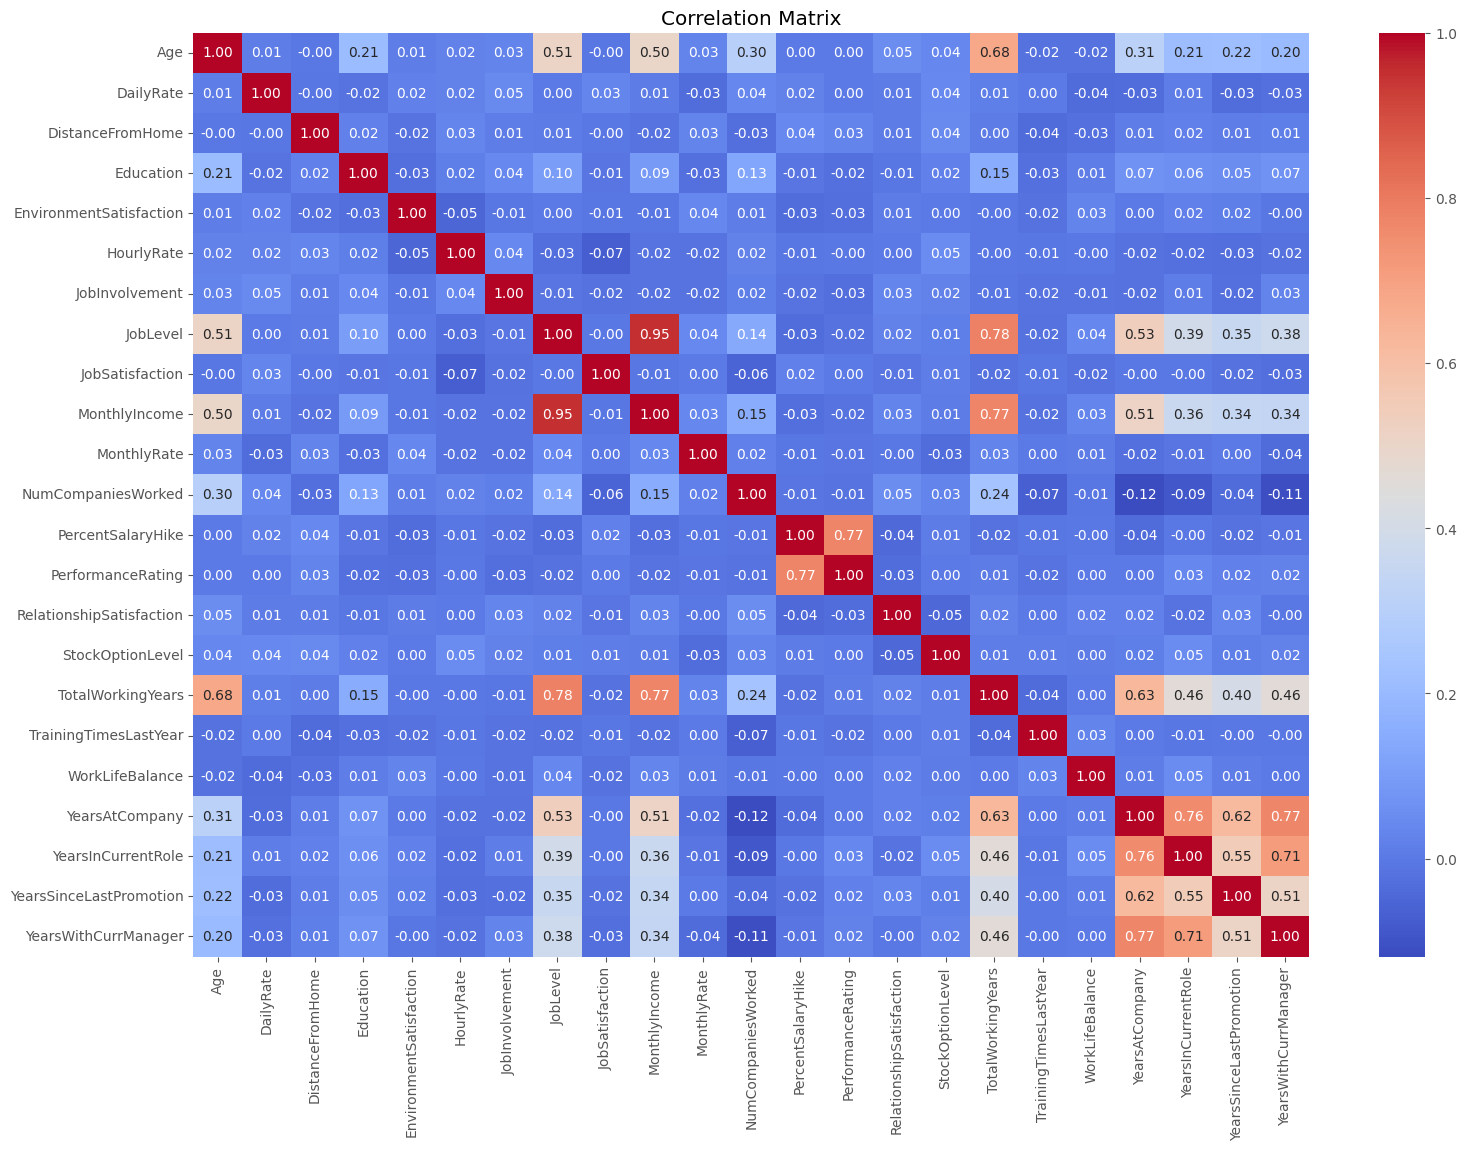

In [36]:
plt.figure(figsize=(18,12))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Step 19:Key Findings

Example observations:

->No missing or duplicate values were identified.   
->Four columns were removed because they provided little analytical value.   
->Overtime employees showed a higher attrition tendency.    
->Monthly income varies across attrition groups.    
->Research & Development and Sales have the largest employee populations.   
->Work-life balance appears related to employee retention.  

Step 20:Final Summary

The employee attrition dataset was cleaned and explored successfully.
After removing non-informative columns, both univariate and bivariate analyses were performed. 
Overtime, monthly income, age, department, and work-life balance emerged as important factors
related to employee attrition. 
The correlation analysis further highlighted relationships among numerical variables, providing
useful insights for HR decision-making and employee retention strategies.